In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import t

In [2]:
data=pd.read_csv('Housing_v2.csv')

Column 'Description' has free and unstructered text, it has approximately 1300 unique descriptions and it is not categorical or numerical value. Its cardinality almost equals the size of dataset. For this reason column 'Description' was deleted. 

In [3]:
data.describe()
data = data.drop(columns=['Description'])

In [4]:
def numeric(df):
  numeric_df = df.select_dtypes(include=["int64", "float64"])
  return numeric_df
def categorical(df):
  categorical_df = df.select_dtypes(include=["object"])
  return categorical_df


In [5]:
cat, num = 0, 0
numeric_df = numeric(data)
categorical_df = categorical(data)
for col in data.columns:
    if col in numeric_df.columns:
        num+=1
    else:
        cat+=1
print(f'Categorical columns: {cat} \nNumerical columns: {num}')

Categorical columns: 1 
Numerical columns: 7


C:\Users\Поліна\AppData\Local\Temp\ipykernel_23344\3150696230.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_df = df.select_dtypes(include=["object"])


In [6]:
def mean(df):
    return sum(df)/len(df)

def median(df):
    sorted_df=sorted(df)
    n=len(sorted_df)
    if n%2==0:
        return(sorted_df[n//2-1]+sorted_df[n//2])/2
    else:
        return sorted_df[n//2]

# how much values deviate from the mean
def std_dev(df):
    m=mean(df)
    return (sum((x-m)**2 for x in df)/len(df))**0.5

# calculate the q-th quantile of a dataset
def calc_quantile(df, q):
  sorted_df=sorted(df)
  n=len(sorted_df)
  pos=q*(n-1)
  idx=int(pos)
  fraction=pos-idx

  if idx+1<n:
    return sorted_df[idx]+fraction*(sorted_df[idx+1]-sorted_df[idx])
  else:
    return sorted_df[idx]

# take the most frequent value in a dataset
def mode(df):
    freq_dict={}
    for d in df:
        freq_dict[d]=freq_dict.get(d,0)+1
    sorted_freq=sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)

    mode1=sorted_freq[0][0] if len(sorted_freq) > 0 else None
    freq_1 = sorted_freq[0][1] if len(sorted_freq) > 0 else 0
    perc1=(freq_1 / len(df)) * 100 

    mode2=sorted_freq[1][0] if len(sorted_freq) > 1 else None
    freq_2 = sorted_freq[1][1] if len(sorted_freq) >1 else 0
    perc2=(freq_2 / len(df)) * 100 
    return mode1, freq_1, perc1, mode2, freq_2, perc2

In [7]:
results=[]
numerical=0
for col in data.columns:
    if col in numeric_df.columns:
        numerical+=1
        total=len(data[col])
        clean_data=data[col].dropna().to_list()

        missing_values = data[col].isnull().sum()
        perc_miss_values=(missing_values / len(data)) * 100
        cardinality=data[col].nunique()

        if len(clean_data) > 0:
            maxim=max(clean_data)
            minim=min(clean_data)
            q1 = calc_quantile(clean_data, 0.25)
            q3 = calc_quantile(clean_data, 0.75)
            mean1=mean(clean_data)
            median1=median(clean_data)
            std1=std_dev(clean_data)
        else:
            maxim = None
            minim = None
            q1 = None
            q3 = None
            mean1 = None
            median1 = None
            std1 = None

        results.append({
        "Variable": col,
        "Total Values": total,
        "Missing Values": missing_values,
        "Missing %": perc_miss_values,
        "Cardinality": cardinality,
        "Minimum": minim,
        "Maximum": maxim,
        "Q1": q1,
        "Q3": q3,
        "Mean": mean1,
        "Median": median1,
        "Standard Deviation": std1
        })

continuous_summary = pd.DataFrame(results)
display(continuous_summary)
print(f"Number of numerical columns: {numerical}")


,Variable,Total Values,Missing Values,Missing %,Cardinality,Minimum,Maximum,Q1,Q3,Mean,Median,Standard Deviation
0,Price,1500,49,3.266667,831,300000.000000,2.500000e+09,4.902000e+06,2.500000e+07,3.282218e+07,9.200000e+06,1.012102e+08
1,Bedrooms,1500,63,4.200000,13,1.000000,1.300000e+01,3.000000e+00,4.000000e+00,3.617954e+00,3.000000e+00,1.373589e+00
2,Bathrooms,1500,80,5.333333,18,1.000000,4.300000e+01,2.000000e+00,4.000000e+00,3.003169e+00,3.000000e+00,1.853382e+00
3,Floor Area,1500,37,2.466667,411,22.000000,2.200000e+03,6.756000e+01,2.500000e+02,2.139252e+02,1.420000e+02,2.365239e+02
4,Land Area,1500,23,1.533333,413,27.000000,2.500000e+04,8.100000e+01,2.400000e+02,2.741740e+02,1.210000e+02,8.892387e+02
5,Latitude,1500,289,19.266667,459,6.128079,1.738806e+01,1.437232e+01,1.491318e+01,1.424123e+01,1.452575e+01,1.749349e+00
6,Longitude,1500,289,19.266667,459,120.228242,1.258038e+02,1.208963e+02,1.210743e+02,1.212031e+02,1.210269e+02,9.899962e-01


Number of numerical columns: 7


In [8]:
results=[]
categorical1=0
for col in data.columns:
    if col in categorical_df.columns:
        categorical1+=1
        total=len(data[col])
        clean_data=data[col].dropna().to_list()

        missing_values = data[col].isnull().sum()
        perc_miss_values=(missing_values / len(data)) * 100
        cardinality=data[col].nunique()
        mode1, freq_1, perc1, mode2, freq_2,perc2 = mode(clean_data)

        results.append({
                    "Variable": col,
                    "Total Values": total,
                    "Missing Values": missing_values,
                    "Missing %": perc_miss_values,
                    "Cardinality": cardinality,
                    "Mode 1": mode1,
                    "Mode 1 Frequency": freq_1,
                    "Mode 1 %": perc1,
                    "Mode 2": mode2,
                    "Mode 2 Frequency": freq_2,
                    "Mode 2 %": perc2
                })


categorical_summary = pd.DataFrame(results)

display(categorical_summary)
print(f"Number of categorical columns: {categorical1}")


,Variable,Total Values,Missing Values,Missing %,Cardinality,Mode 1,Mode 1 Frequency,Mode 1 %,Mode 2,Mode 2 Frequency,Mode 2 %
0,Location,1500,4,0.266667,664,"Emilio Vergara Hwy Santa Arcadia, Cabanatuan",71,4.745989,"MacArthur Hwy Anonas, Urdaneta",59,3.94385


Number of categorical columns: 1


1. 'Price' has a right-skewed distribution. Most values are concentrated on the left side (standard affordable properties), while the long tail extends to the right up to $2.5 \times 10^9$, representing a few elite properties (outliers).
2.'Bedrooms' has a right-skewed distribution with peaks at 3-4 bedrooms, which dominate the market. However, notable anomalies appear at 10–12 bedrooms, which likely represent outliers or hotels.
3.'Bathrooms' is right-skewed, with 2–3 bathrooms being the most common. The tail on the right side needs to be checked for potential outliers.
4.'Floor Area' follows an exponential right-skewed distribution. The majority of houses have small to average floor areas, but there are visible enormous areas that stretch the tail.
5.'Land Area' shows extreme right-asymmetry. Almost all properties are clustered near minimal values, while the tail stretches out to 25,000 for properties with large land plots.
6.'Latitude' and 'Longitude' show multimodal distributions with peaks. For latitude, the main peak is around 14–15 degrees with smaller clusters near 7, 10, and 16 degrees. For longitude, the highest peak is near 121 degrees with smaller clusters around 123–125 degrees.

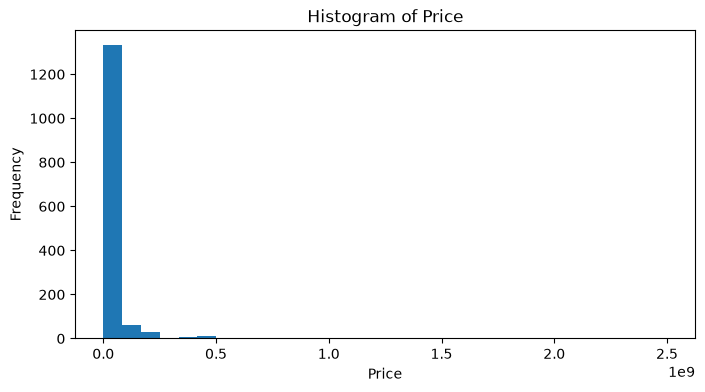

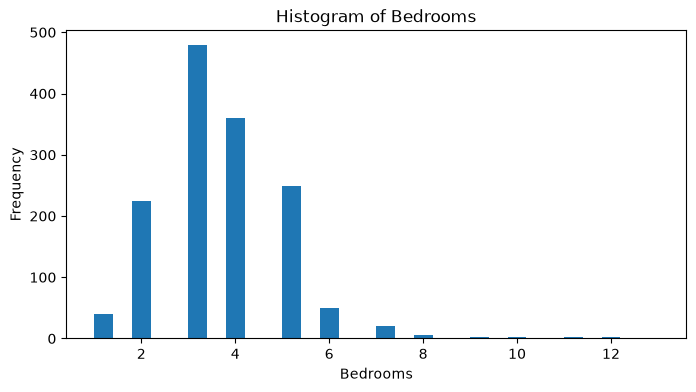

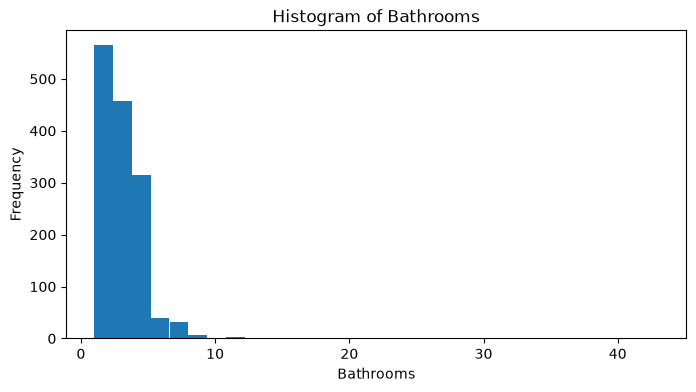

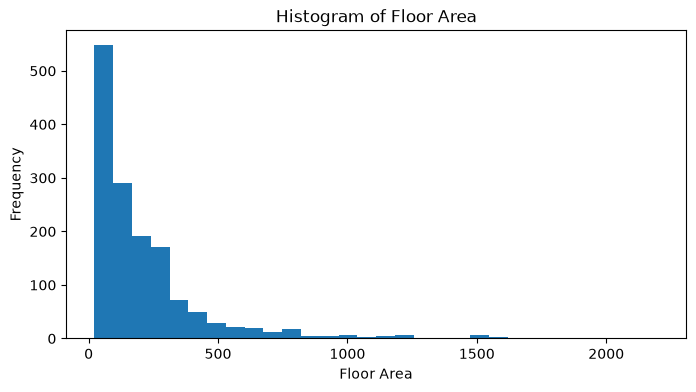

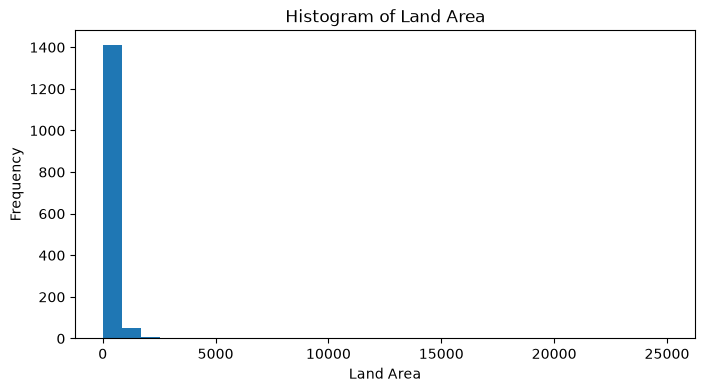

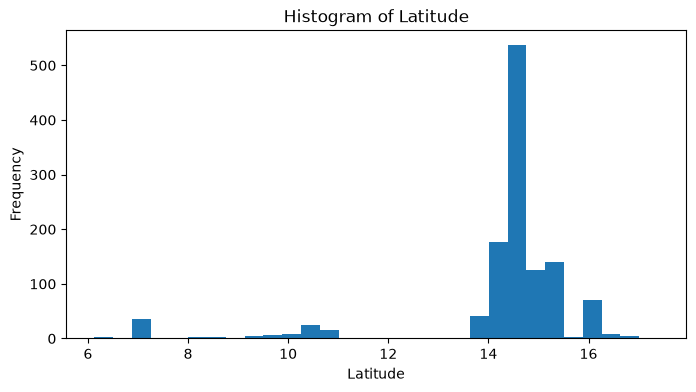

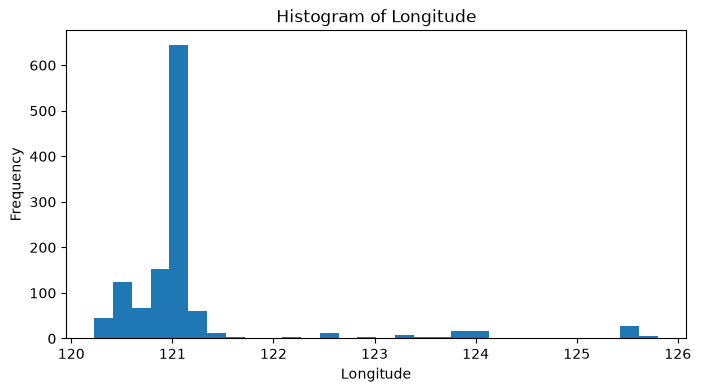

In [9]:
for col in numeric_df:
    plt.figure(figsize=(8, 4))
    data[col].dropna().plot(kind='hist', bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


Numerical feature columns with missing data points will be imputed using the median calculated from the training dataset, and categorical columns using the mode (also from the training dataset). The target `Price` is never imputed: rows without a price were dropped earlier.
I use the median because it is robust to outliers. The mean is affected by every value, so a few very expensive houses would pull it up, while the median simply takes the middle value of the sorted list. The statistics are calculated only on the training set to prevent data leakage: if they were computed on the whole dataset, information from the test set would leak into training.

In [10]:
total_miss_values = data.isnull().sum().sum()
perc = (total_miss_values / data.size) * 100
print(
    f"Total missing values in dataset:\n{total_miss_values}\n"
    f"Total percentage of missing values:\n{perc:.2f}%\n")

Total missing values in dataset:
834
Total percentage of missing values:
6.95%



Outliers were detected using the Interquartile Range, or IQR, method. First, I calculate Q1 and Q3 and then the IQR as Q3 minus Q1. Based on the IQR, I calculate the lower and upper bounds. Any values outside these bounds are considered outliers. At this stage, I only detect and count the outliers, I do not modify them yet. Later, instead of deleting these observations, I use IQR capping, where extreme values are limited to the calculated lower or upper bound. This is useful for real estate data because expensive or unusually large properties can still be valid observations. Capping allows me to keep these observations while reducing their extreme influence on the linear regression model.

In [11]:
for col in data.columns:
  if data[col].dtype in ["int64", "float64"]:
    #clean from missing values
    clean_vals = data[col].dropna().tolist()
    if len(clean_vals) > 0:
      q1=calc_quantile(clean_vals , 0.25)
      q3=calc_quantile(clean_vals, 0.75)
      iqr = q3 - q1
      lower_bound = q1 - 1.5 * iqr
      upper_bound = q3 + 1.5 * iqr
      outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]
      outliers_perc = (outliers / len(data)) * 100
      print(f'Column: {col}\n')
      print(f'Number of outliers: {outliers}')
      print(f'Percentage of outliers: {outliers_perc}%\n')

Column: Price

Number of outliers: 162
Percentage of outliers: 10.8%

Column: Bedrooms

Number of outliers: 125
Percentage of outliers: 8.333333333333332%

Column: Bathrooms

Number of outliers: 12
Percentage of outliers: 0.8%

Column: Floor Area

Number of outliers: 113
Percentage of outliers: 7.533333333333333%

Column: Land Area

Number of outliers: 156
Percentage of outliers: 10.4%

Column: Latitude

Number of outliers: 190
Percentage of outliers: 12.666666666666668%

Column: Longitude

Number of outliers: 327
Percentage of outliers: 21.8%



Fully duplicated rows will be dropped. Duplicates introduce artificial weight to specific observations and can bias model during training and cross validation. 

In [12]:
duplicates_count = data.duplicated().sum()
print(f"Number of duplicates: {duplicates_count}")

data = data.drop_duplicates()
print(f"Number of duplicates after: {data.duplicated().sum()}")

Number of duplicates: 114
Number of duplicates after: 0


Rows with missing `Price` are dropped: the target must never be imputed (an imputed price is not a real label, and it would leak the imputation rule into both training and evaluation). Rows that contain 0 or a negative value for Price or Floor Area are also removed, because such values are impossible and point to a data collection error. Invalid values in the other columns were checked separately and none were found.

In [13]:
invalid_prices = data[data["Price"] <= 0].shape[0]
invalid_area = data[data["Floor Area"] <= 0].shape[0]
missing_price = data["Price"].isnull().sum()
print(f"Missing Price (target): {missing_price}")
print(f"Invalid price values (<= 0): {invalid_prices}")
print(f"Invalid area values (<= 0): {invalid_area}")

# rows without a target cannot be used for supervised learning and must not be imputed
data = data.dropna(subset=["Price"])
# invalid rows (NaN in Floor Area is kept here on purpose: it is imputed later using train statistics only)
data = data[(data["Price"] > 0) & ~(data["Floor Area"] <= 0)]
print(f"Rows left: {len(data)}")

Missing Price (target): 46
Invalid price values (<= 0): 0
Invalid area values (<= 0): 0
Rows left: 1340


Scatter plot shows relationship between Floor Area(x) and Price(y). Most data points are clustered at the bottom left, showing small properties with lower prices. Trend is visible, where properties with larger floor areas command hihger prices, extending to outlier with floor area over 2000 and price reaching  $2.5 \times 10^9$.

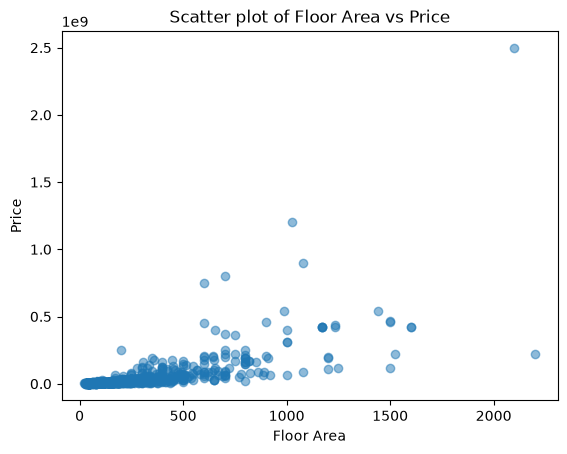

In [14]:
x=data['Floor Area']
y=data['Price']

plt.scatter(x, y, alpha=0.5)
plt.title('Scatter plot of Floor Area vs Price')
plt.xlabel('Floor Area')
plt.ylabel('Price')
plt.show()

The SPLOM visualizes pairwise relationships among all continuous variables (Price, Floor Area, Land Area, Bedrooms, Bathrooms) with histograms along the diagonal. It illustrates that Floor Area has a strong positive linear correlation with Price, while other variables like Land Area show weaker dispersion patterns and multimodal characteristics.

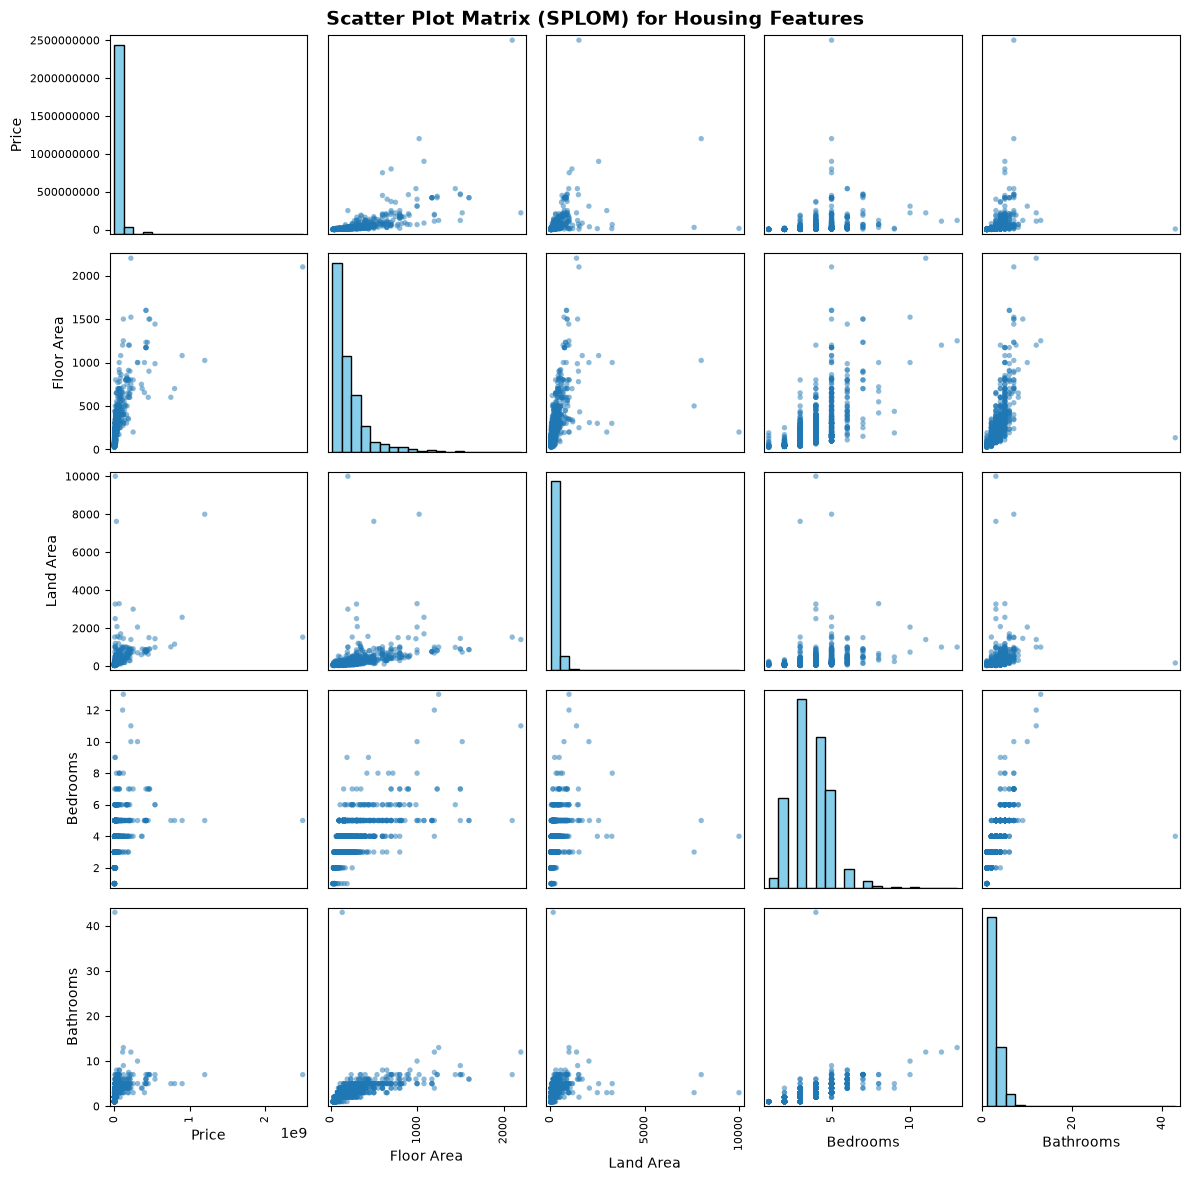

In [15]:
cols_for_splom = ["Price", "Floor Area", "Land Area", "Bedrooms", "Bathrooms"]
splom_data = data[cols_for_splom].dropna()
pd.plotting.scatter_matrix(
    splom_data,
    figsize=(12, 12),
    marker="o",
    hist_kwds={"bins": 20, "color": "skyblue", "edgecolor": "black"},
    alpha=0.5,  # Transparency for overlapping data points
    s=15,  # Marker size
)
plt.suptitle(
    "Scatter Plot Matrix (SPLOM) for Housing Features",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

This box plot compares the distribution of Price across different numbers of Bedrooms. The median price tends to increase moderately as the number of bedrooms grows up to 7–8, and categories like 5 bedrooms contain numerous high-end price outliers stretching up to $2.5 \times 10^9$.

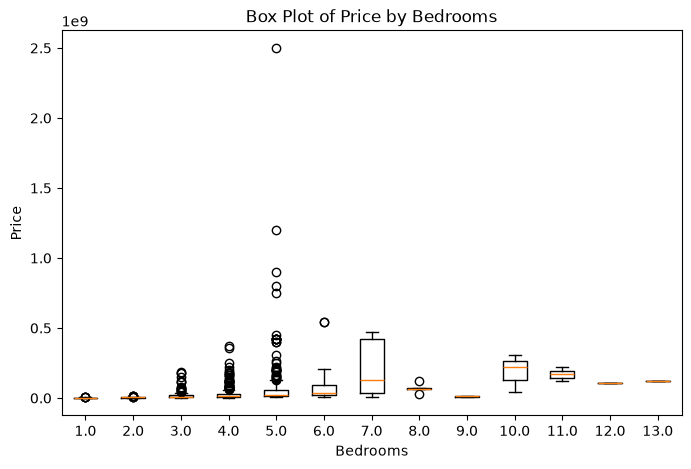

In [16]:
df_clean = data.dropna(subset=["Bedrooms", "Price"])
unique_bedrooms = sorted(df_clean["Bedrooms"].unique())
box_data = [df_clean[df_clean["Bedrooms"] == b]["Price"] for b in unique_bedrooms]

plt.figure(figsize=(8, 5))
plt.boxplot(box_data, tick_labels=unique_bedrooms)
plt.title("Box Plot of Price by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

This bar chart highlights the top 10 locations sorted by their average Price. Locations such as "Forbes Park, Makati" significantly outrank others, with average prices reaching up to $2.5 \times 10^9$, indicating exclusive elite neighborhoods.

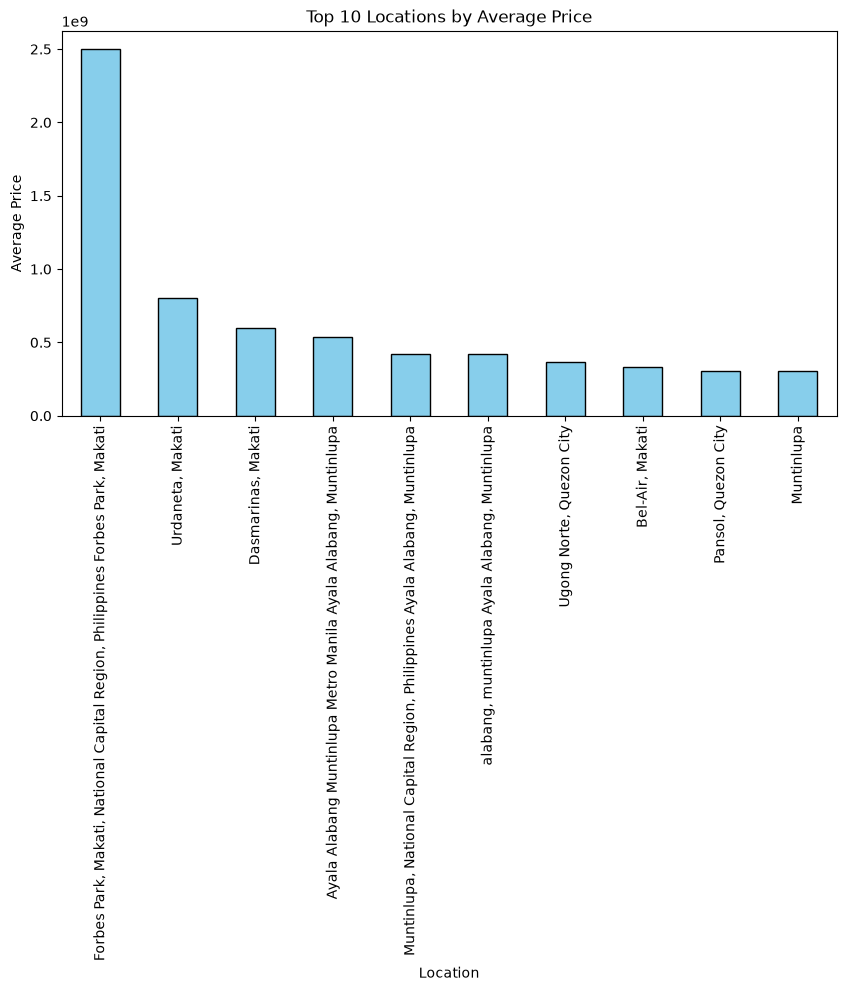

In [17]:
top_locations = (
    data.groupby("Location")["Price"].mean().nlargest(10))

plt.figure(figsize=(10, 5))
top_locations.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Top 10 Locations by Average Price")
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.show()

 The correlation matrix heatmap displays Pearson correlation coefficients between continuous variables. Floor Area shows the strongest positive correlation with Price ($r = 0.68$), followed by Bathrooms ($r = 0.33$) and Land Area ($r = 0.32$). Latitude and longitude exhibit a strong negative correlation with each other ($r = -0.94$) but have virtually no linear relationship with price.

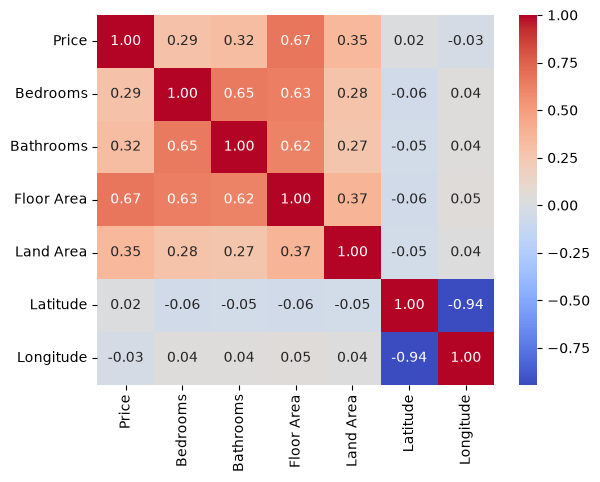

In [18]:
num=numeric(data)
correlation_matrix = num.corr()
ax=sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)


In [19]:
def train_test(df, test_size=0.2, seed=42):
    n = len(df)
    # shuffle the rows with a fixed seed so the split does not depend on the order of the file
    idx = np.random.default_rng(seed).permutation(n)
    train_size = int(n * (1 - test_size))
    # iloc is used to select rows by index position
    return df.iloc[idx[:train_size]], df.iloc[idx[train_size:]]

train_data, test_data = train_test(data, test_size=0.2)
print(f"Train: {len(train_data)} rows, Test: {len(test_data)} rows")

Train: 1072 rows, Test: 268 rows


In [ ]:
train_num_col=numeric(train_data).columns
train_cat_col=categorical(train_data).columns

train_medians={}
for col in train_num_col:
    # dropna() is used to remove missing values before calculating the median
    clean_vals=train_data[col].dropna().tolist()
    train_medians[col]=median(clean_vals)

train_modes={}
for col in train_cat_col:
    clean_vals=train_data[col].dropna().tolist()
    train_modes[col]=mode(clean_vals)[0]

def fill_missing_values(df):
    df_copy=df.copy()
    for col, val in train_medians.items():
        if col in df_copy.columns:
            df_copy[col]=df_copy[col].fillna(val)
    for col, val in train_modes.items():
        if col in df_copy.columns:
            df_copy[col]=df_copy[col].fillna(val)
    return df_copy

train_data=fill_missing_values(train_data)
test_data=fill_missing_values(test_data)


C:\Users\Поліна\AppData\Local\Temp\ipykernel_23344\3150696230.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_df = df.select_dtypes(include=["object"])


First, I calculate the IQR bounds using only the training data. Then I apply capping to both training and test data using these same bounds. Values below the lower bound are replaced with the lower bound, and values above the upper bound are replaced with the upper bound. I do not delete the observations. Also, I do not calculate new bounds from the test set, because that would introduce data leakage.

Geographical coordinates cannot be clipped using the IQR method. If quartile bounds are applied to them, the model would simply "drop" entire real city districts located on the outskirts or situated further away on the map.
Floor and land areas have a large range and right-side asymmetry (median is 121, while the maximum is 25,000). Clipping via IQR stabilizes the distribution.

In [21]:
outlier_columns = ['Price','Bedrooms','Bathrooms','Floor Area','Land Area']
train_iqr={}
for col in outlier_columns:
    clean_vals=train_data[col].dropna().tolist()
    if clean_vals:
        q1=calc_quantile(clean_vals, 0.25)
        q3=calc_quantile(clean_vals, 0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        train_iqr[col] = (lower_bound, upper_bound)

def cap_outliers(df):
    df_copy=df.copy()
    for col, (lower_bound, upper_bound) in train_iqr.items():
        df_copy[col]=df_copy[col].apply(lambda x: max(lower_bound, min(upper_bound, x)))
    return df_copy

train_data=cap_outliers(train_data)
test_data=cap_outliers(test_data)


In [22]:
train_data['Total_Rooms'] = train_data['Bedrooms'] + train_data['Bathrooms']
train_data['Total_Area'] = train_data['Floor Area'] + train_data['Land Area']
test_data['Total_Rooms'] = test_data['Bedrooms'] + test_data['Bathrooms']
test_data['Total_Area'] = test_data['Floor Area'] + test_data['Land Area']
train_data["Area_Per_Room"] = train_data["Total_Area"] / train_data["Total_Rooms"]
train_data["Floor_To_Land_Ratio"] = (train_data["Floor Area"] / train_data["Land Area"])
test_data["Area_Per_Room"] = test_data["Total_Area"] / test_data["Total_Rooms"]
test_data["Floor_To_Land_Ratio"] = (test_data["Floor Area"] / test_data["Land Area"])

train_num_col = numeric(train_data).columns

**Target Encoding of `Location`**
`Location` has very high cardinality (664 unique values, and 465 of them occur only once), so One-Hot Encoding would create hundreds of sparse columns. Target Encoding replaces each location with a value derived from the price.

A naive version (mean price of the location computed on the whole training set and then written back into the training rows) has a serious **target leakage**: for a location that appears once, the encoded feature is *exactly the price of that same row*, so the model gets the answer as a feature. The training error looks great, but the model does not generalize. Two changes fix this:

1. **Out-of-fold encoding for the training set.** The training set is split into K folds, and the encoding of every row is computed only from the *other* folds, so a row never sees its own price.
2. **Smoothing.** `enc = (n * loc_mean + m * global_mean) / (n + m)`. Rare locations are pulled towards the global mean instead of trusting one or two prices.

The mapping for the test set and for new records is fitted on the whole training set. Unknown locations get the global mean (the formula gives it automatically when `n = 0`). The same idea is used inside every cross-validation fold below.

In [ ]:
# if location meets once, we use smoothing to avoid overfitting
TE_SMOOTHING = 10   

TE_FOLDS = 5        
TE_SEED = 42

# Function to fit target encoding
def fit_target_encoding(locations, y, smoothing=TE_SMOOTHING):
    # convert locations to a numpy array of strings and y to a numpy array of floats
    locs = np.asarray(locations).astype(str)
    # convert Price values to a numpy array of floats
    y = np.asarray(y, dtype=float)
    # get unique locations and their inverse indices
    uniq, inv = np.unique(locs, return_inverse=True)
    # return the sum of y for each unique location and the count of occurrences for each unique location
    sums = np.bincount(inv, weights=y)
    counts = np.bincount(inv)
    # return the global mean of y
    g_mean = y.mean()
    # compute the smoothed target encoding for each unique location
    enc = (sums + smoothing * g_mean) / (counts + smoothing)
    return dict(zip(uniq, enc)), g_mean

# Function to apply target encoding
def apply_target_encoding(locations, enc_map, g_mean):
    # return the encoded values for the given locations using the encoding map, defaulting to the global mean for unseen locations
    return np.array([enc_map.get(l, g_mean) for l in np.asarray(locations).astype(str)])

def oof_target_encode(locations, y, k=TE_FOLDS, smoothing=TE_SMOOTHING, seed=TE_SEED):
    locations = np.asarray(locations).astype(str)
    y = np.asarray(y, dtype=float)
    n = len(y)
    # permutation mix indexes for k-fold cross-validation
    folds = np.array_split(np.random.default_rng(seed).permutation(n), k)
    # create an empty array to hold the encoded values
    encoded = np.empty(n)
    for fold in folds:
        # create a boolean mask for the current fold
        mask = np.ones(n, dtype=bool)
        # do not use the current fold for fitting the encoding map
        mask[fold] = False
        enc_map, g_mean = fit_target_encoding(locations[mask], y[mask], smoothing)
        encoded[fold] = apply_target_encoding(locations[fold], enc_map, g_mean)
    return encoded

train_locations_for_cv = train_data['Location'].copy()
#For training data, OOF encoding prevents an observation's own target from influencing its encoded feature. 
#For test data, the mapping can be fitted on the complete training set because test targets are never used in the mapping.
location_price_map, global_mean_price = fit_target_encoding(train_data['Location'], train_data['Price'])
train_data['Location_encoded'] = oof_target_encode(train_data['Location'], train_data['Price'])
test_data['Location_encoded'] = apply_target_encoding(test_data['Location'], location_price_map, global_mean_price)
train_data = train_data.drop(columns=['Location'])
test_data = test_data.drop(columns=['Location'])

Removing `Longitude` makes complete sense. Latitude and longitude tell us almost the same story on a map and overlap heavily. Since they don't connect strongly to the price on their own, keeping both in a linear regression is a waste and just duplicates data. Removing one keeps the model cleaner and more stable.

In [24]:
train_data = train_data.drop(columns=['Longitude'])
test_data = test_data.drop(columns=['Longitude'])
train_num_col = numeric(train_data).columns

In [25]:
train_cat_col_for_encoding = [c for c in train_cat_col if c != 'Location']  
unique={}
for col in train_cat_col_for_encoding:     
    unique[col]=sorted(train_data[col].unique().tolist())

for col, cats in unique.items():
    print(f"Column '{col}': {cats}")

def one_hot_encode(df):
    df_copy=df.copy()
    for col, cats in unique.items():
        if col not in df_copy.columns:
            continue
        cats_to_encode = cats[1:]
        for cat in cats_to_encode:
            new_col_name=f"{col}_{cat}"
            binary_values=[]
            for val in df_copy[col]:
                if val==cat:
                    binary_values.append(1)
                else:
                    binary_values.append(0)
            df_copy[new_col_name]=binary_values
        df_copy=df_copy.drop(columns=[col])
    return df_copy          

train_data=one_hot_encode(train_data)
test_data=one_hot_encode(test_data)

Price isn't normalized for such reasons:
Clear metrics: Model errors (like MAE or RMSE) are shown in real money, not abstract numbers from 0 to 1.
Simple math: Regularization only affects input features (X), leaving the target variable (y) untouched.
Easy predictions: The model predicts real prices directly without needing an extra reverse-transform step.

In [26]:
train_min={}
train_max={}
cols_to_normalize = [c for c in train_num_col if c != 'Price']

for col in cols_to_normalize:
    clean_vals=train_data[col].dropna().tolist()
    if clean_vals:
        train_min[col]=min(clean_vals)
        train_max[col]=max(clean_vals)

def normalize(df):
    df_copy=df.copy()
    for col in cols_to_normalize:          
        if col in df_copy.columns:
            min_val=train_min[col]
            max_val=train_max[col]
            if max_val != min_val:
                df_copy[col] = (df_copy[col] - min_val) / (max_val - min_val)
            else:
                df_copy[col] = 0.0
    return df_copy

train_data = normalize(train_data)
test_data = normalize(test_data)

In [27]:
print(train_data.describe().loc[['min', 'max']])

          Price  Bedrooms  Bathrooms  Floor Area  Land Area  Latitude  \
min    300000.0       0.0        0.0         0.0        0.0       0.0   
max  55000000.0       1.0        1.0         1.0        1.0       1.0   

     Total_Rooms  Total_Area  Area_Per_Room  Floor_To_Land_Ratio  \
min          0.0         0.0            0.0                  0.0   
max          1.0         1.0            1.0                  1.0   

     Location_encoded  
min               0.0  
max               1.0  


In [28]:
X_train_df = train_data.drop(columns=['Price'])
y_train_series = train_data['Price']
X_train_list = X_train_df.values.tolist()
y_train_list = y_train_series.tolist()

X_test_df = test_data.drop(columns=['Price'])
y_test_series = test_data['Price']
X_test_list = X_test_df.values.tolist()
y_test_list = y_test_series.tolist()

In [ ]:
# I added a bias term to calculate intercept with all other coefficients, so we can use the same formula for all coefficients
def add_bias(X_list):
    X_train_with_bias=[]
    for i in range(len(X_list)):
        row=[1.0]
        for j in range(len(X_list[i])):
            row.append(X_list[i][j])
        X_train_with_bias.append(row)
    return X_train_with_bias

X_train_with_bias=add_bias(X_train_list)
X_np=np.array(X_train_with_bias)
y_np=np.array(y_train_list)

#least squared(make minimal sum of squared errors)
def least_squared():
    theta_osl=np.linalg.pinv(X_np.T@X_np)@X_np.T@y_np
    return theta_osl.tolist()

coefficients_osl=least_squared()
print("Coefficients from osl:")
print(coefficients_osl)

Coefficients from osl:
[-7067270.096661459, -7174122.937082593, 807055.0907262671, 23965246.287237924, 20744234.74778091, 7340014.07063412, -2385416.1203983966, 22960197.18583244, -27037268.916712537, 18102972.488554843, 13828035.22213136]


In [30]:
def compute_gradient(X_np, y_np, theta):
    m=len(y_np)
    X_transpose=X_np.T
    predictions=X_np@theta
    error=predictions-y_np
    # how loss changes with respect to each coefficient, 
    # we can use the gradient to update the coefficients in the direction that reduces the loss
    grad=(1/m)*(X_transpose@error)
    return grad

def gradient_descend(X_with_bias, y_train_list, learning_rate=0.1, epochs=10000):
    X_np=np.array(X_with_bias)
    y_np=np.array(y_train_list).reshape(-1)

    m,n=X_np.shape
    theta_gd=np.zeros(n)
    for epoch in range(epochs):
        grad=compute_gradient(X_np, y_np, theta_gd)
        # update the coefficients in the direction that reduces the loss
        theta_gd=theta_gd-learning_rate*grad
    return theta_gd.tolist()

GD_LR = 0.5
GD_EPOCHS = 50000

coefficients_grad = gradient_descend(X_train_with_bias, y_train_list, learning_rate=GD_LR, epochs=GD_EPOCHS)
print("Coefficients from gradient desc:")
print(coefficients_grad)

Coefficients from gradient desc:
[-7067270.096661552, -7174122.937082767, 807055.0907266656, 23965246.287236705, 20744234.74777936, 7340014.07063387, -2385416.1203970094, 22960197.18583257, -27037268.91671006, 18102972.4885541, 13828035.222131567]


With `GD_LR = 0.5` and `GD_EPOCHS = 50000` the Gradient Descent coefficients coincide with the Least Squares (normal equation) solution. For example, the intercept b0 is -7.067270e+06 in both methods, and b_1 is -7.174123e+06. The absolute difference in the last column is about 1e-6 for every coefficient (less than one millionth on values of the order of 1e7).

A smaller learning rate / fewer epochs (0.05 / 2000) gives visibly different coefficients, because the features are scaled to [0, 1] and some of them are perfectly collinear (`Total_Rooms = Bedrooms + Bathrooms`, `Total_Area = Floor Area + Land Area`), which makes the problem badly conditioned. Because of this collinearity the individual coefficients are not uniquely interpretable, but the predictions are.

In [31]:
grad=np.array(coefficients_grad)
osl=np.array(coefficients_osl)
parameter_names = [f'b_{i}' for i in range(len(osl))]
parameter_names[0] = 'Intercept, b0'  
results_df = pd.DataFrame({
    'Parameter': parameter_names,
    'Least squared': osl,
    'Gradient desc': grad,
    'Absolute difference': np.abs(osl - grad),
})


print(results_df.head(10).to_string(index=False))

    Parameter  Least squared  Gradient desc  Absolute difference
Intercept, b0  -7.067270e+06  -7.067270e+06         9.313226e-08
          b_1  -7.174123e+06  -7.174123e+06         1.732260e-07
          b_2   8.070551e+05   8.070551e+05         3.984896e-07
          b_3   2.396525e+07   2.396525e+07         1.218170e-06
          b_4   2.074423e+07   2.074423e+07         1.553446e-06
          b_5   7.340014e+06   7.340014e+06         2.505258e-07
          b_6  -2.385416e+06  -2.385416e+06         1.387205e-06
          b_7   2.296020e+07   2.296020e+07         1.303852e-07
          b_8  -2.703727e+07  -2.703727e+07         2.477318e-06
          b_9   1.810297e+07   1.810297e+07         7.413328e-07


In [ ]:
X_np = np.array(X_train_with_bias)
y_np = np.array(y_train_list)
# n-number of observations, p-number of columns in X
n, p = X_np.shape  
theta_osl = np.array(coefficients_osl)
# y=X*theta
predictions = X_np @ theta_osl
# calculate residuals(how much noise left after fitting the model)
residuals = y_np - predictions
# variance of the residuals, which is an estimate of the variance of the error term in the regression model
# n-p because we already estimated p coefficients, so we lose p degrees of freedom
residual_variance = (residuals.T @ residuals) / (n - p)
# uncertainty all estimated coefficients
cov_matrix = residual_variance * np.linalg.pinv(X_np.T @ X_np)
# standard errors for each coefficient are the square roots of the diagonal elements of the covariance matrix
# if small - more precise coefficients, if large - less precise coefficients
std_errors = np.sqrt(np.diagonal(cov_matrix))
# how far located coefficients from zero, if t-statistic is large, it means that the coefficient is significantly different from zero
t_stats = theta_osl / std_errors
# two-tailed p-values for the t-statistics
# Assuming the null hypothesis is true, the p-value is the probability of observing 
# a t-statistic at least as extreme as the one obtained.
p_values = 2 * (1 - t.cdf(np.abs(t_stats), df=n - p))
all_names = ['Intercept'] + X_train_df.columns.tolist()

coef_table = pd.DataFrame({
    'Feature': all_names,
    'Coefficient': theta_osl,
    'Std. Error': std_errors,
    't-statistic': t_stats,
    'p-value': p_values
})

pd.set_option('display.max_rows', None)
print("Coefficient Statistical Significance Table")
print(coef_table.to_string(index=False))
print()
feature_names = X_train_df.columns.tolist()
significant_vars = []

for idx, p_val in enumerate(p_values[1:], start=1):
    if p_val < 0.05:
        significant_vars.append(feature_names[idx - 1])

X_all_df = X_train_df
X_sig_df = X_train_df[significant_vars]
p_val_features = list(zip(feature_names, p_values[1:]))
p_val_features.sort(key=lambda x: x[1])
top3_vars = [item[0] for item in p_val_features[:3]]
X_top3_df = X_train_df[top3_vars]
print(f"Significant variables (p < 0.05): {significant_vars}")
print(f"Top 3 variables: {top3_vars}")

Coefficient Statistical Significance Table
            Feature   Coefficient   Std. Error  t-statistic      p-value
          Intercept -7.067270e+06 1.748225e+06    -4.042540 5.669649e-05
           Bedrooms -7.174123e+06 1.627871e+06    -4.407059 1.154245e-05
          Bathrooms  8.070551e+05 2.100141e+06     0.384286 7.008434e-01
         Floor Area  2.396525e+07 2.273575e+06    10.540779 0.000000e+00
          Land Area  2.074423e+07 2.809717e+06     7.383034 3.121947e-13
           Latitude  7.340014e+06 1.828233e+06     4.014814 6.367833e-05
        Total_Rooms -2.385416e+06 1.137166e+06    -2.097686 3.616900e-02
         Total_Area  2.296020e+07 1.500913e+06    15.297492 0.000000e+00
      Area_Per_Room -2.703727e+07 4.715367e+06    -5.733863 1.279071e-08
Floor_To_Land_Ratio  1.810297e+07 3.628809e+06     4.988681 7.099318e-07
   Location_encoded  1.382804e+07 1.929537e+06     7.166505 1.438183e-12

Significant variables (p < 0.05): ['Bedrooms', 'Floor Area', 'Land Area', 'Latit

I use five-fold cross-validation on the training data to estimate how well each feature configuration generalizes. In each fold, one part is used for validation and the remaining parts for training. Because Location target encoding depends on Price, I recalculate it inside every fold using only the current training portion, which prevents validation-target leakage. I train the regression model using Gradient Descent on that training portion, predict the validation fold, calculate its MSE, and repeat this for all five folds. Finally, I compare the mean and standard deviation of the five MSE scores across the different feature sets.

In [33]:
def cross_validation(X_df, y_list, k=5, learning_rate=GD_LR, epochs=GD_EPOCHS):
    X_data = X_df.values.copy()
    y_arr = np.array(y_list, dtype=float)
    fold_size = len(X_data) // k
    mse_scores = []
    # get the index of the 'Location_encoded' column if it exists, otherwise set it to None
    location_col_idx = X_df.columns.get_loc('Location_encoded') if 'Location_encoded' in X_df.columns else None
    locations = train_locations_for_cv.to_numpy().astype(str)

    for i in range(k):
        start_idx = i * fold_size
        end_idx = (i + 1) * fold_size if i != k - 1 else len(X_data)

        train_idx = np.r_[np.arange(0, start_idx), np.arange(end_idx, len(X_data))]
        val_idx = np.arange(start_idx, end_idx)

        X_trn = X_data[train_idx].copy()
        X_val = X_data[val_idx].copy()
        y_trn = y_arr[train_idx]
        y_val = y_arr[val_idx]

        if location_col_idx is not None:
            trn_encoded = oof_target_encode(locations[train_idx], y_trn)
            fold_map, fold_mean = fit_target_encoding(locations[train_idx], y_trn)
            val_encoded = apply_target_encoding(locations[val_idx], fold_map, fold_mean)

            f_min, f_max = trn_encoded.min(), trn_encoded.max()
            if f_max != f_min:
                X_trn[:, location_col_idx] = (trn_encoded - f_min) / (f_max - f_min)
                X_val[:, location_col_idx] = (val_encoded - f_min) / (f_max - f_min)
            else:
                X_trn[:, location_col_idx] = 0.0
                X_val[:, location_col_idx] = 0.0

        X_trn = np.c_[np.ones(X_trn.shape[0]), X_trn]
        X_val = np.c_[np.ones(X_val.shape[0]), X_val]

        theta = gradient_descend(X_trn, y_trn.tolist(), learning_rate=learning_rate, epochs=epochs)

        predictions = X_val @ np.array(theta)
        mse_scores.append(np.mean((predictions - y_val) ** 2))

    return mse_scores

Results: the model with all variables and the model with the significant variables have exactly the same Mean MSE (6.81×10¹³) and the same standard deviation (2.24×10¹³). This is expected: `Bathrooms` (the only removed variable) is a linear combination of `Bedrooms` and `Total_Rooms`, so both models span the same space and give identical predictions. The Top 3 model (`Floor Area`, `Total_Area`, `Land Area`) is worse: Mean MSE 7.76×10¹³ with a higher deviation of 2.39×10¹³. So, after removing the leakage, dropping features down to three does **not** help; the location, latitude and room features carry useful signal.

In [34]:
mse_all = cross_validation(X_all_df, y_train_list, k=5)
mse_sig = cross_validation(X_sig_df, y_train_list, k=5)
mse_top3 = cross_validation(X_top3_df, y_train_list, k=5)

summary_df = pd.DataFrame({
    "Model Case": ["ii. Top 3 Variables", "i. Significant Variables", "iii. All Variables"],
    "Mean MSE": [np.mean(mse_top3), np.mean(mse_sig), np.mean(mse_all)],
    "Std Dev MSE": [np.std(mse_top3), np.std(mse_sig), np.std(mse_all)]
})

print(summary_df.to_string(index=False))               

              Model Case     Mean MSE  Std Dev MSE
     ii. Top 3 Variables 7.760242e+13 2.394683e+13
i. Significant Variables 6.807654e+13 2.244572e+13
      iii. All Variables 6.807654e+13 2.244572e+13


The box plot confirms the table: the "Significant" and "All" boxes are identical (median about 6.1×10¹³), while the "Top 3" box is shifted up (median about 7.0×10¹³). The spread between folds is large for all models, because a few very expensive properties in a fold can dominate the MSE. Differences between the models should therefore be read together with this variability.

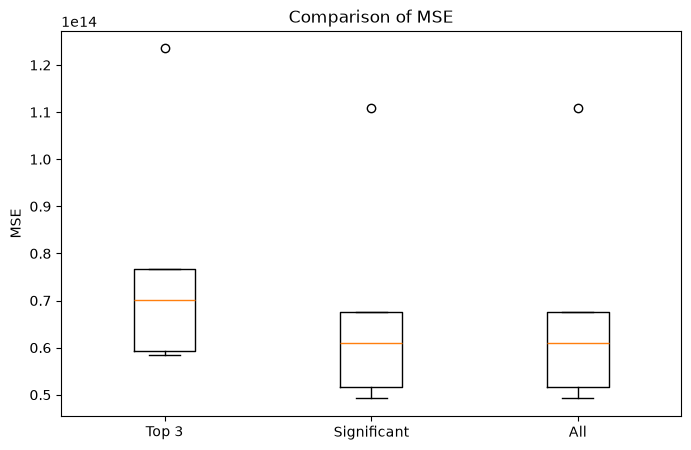

In [35]:
plt.figure(figsize=(8,5))
plt.boxplot([mse_top3, mse_sig, mse_all], tick_labels=["Top 3", "Significant", "All"])
plt.title("Comparison of MSE")
plt.ylabel("MSE")
plt.show()

In [36]:
X_test_top3 = X_test_df[X_top3_df.columns].values
X_test_sig = X_test_df[X_sig_df.columns].values
X_test_all = X_test_df.values
X_test_top3_bias = np.c_[np.ones(X_test_top3.shape[0]), X_test_top3]
X_test_sig_bias = np.c_[np.ones(X_test_sig.shape[0]), X_test_sig]
X_test_all_bias = np.c_[np.ones(X_test_all.shape[0]), X_test_all]

theta_top3 = gradient_descend(np.c_[np.ones(X_top3_df.shape[0]), X_top3_df.values],y_train_list,learning_rate=GD_LR,epochs=GD_EPOCHS,)
theta_sig = gradient_descend(np.c_[np.ones(X_sig_df.shape[0]), X_sig_df.values],y_train_list,learning_rate=GD_LR,epochs=GD_EPOCHS,)
theta_all = gradient_descend(X_train_with_bias,y_train_list,learning_rate=GD_LR,epochs=GD_EPOCHS,)

pred_top3 = X_test_top3_bias @ theta_top3
pred_sig = X_test_sig_bias @ theta_sig
pred_all = X_test_all_bias @ theta_all

y_test_arr = np.array(y_test_list)

On the test set the Significant and All Variables models are identical (MSE 5.356×10¹³, RMSE 7.318×10⁶, MAE 5.107×10⁶, R² ≈ 0.82). The Top 3 model has a higher MSE (5.767×10¹³) and RMSE (7.594×10⁶, R² ≈ 0.80), but a lower MAE (4.855×10⁶): it makes slightly smaller typical errors, and larger errors on a few expensive houses, which MSE punishes more.

This agrees with cross-validation, where Top 3 was also worse in MSE. The test MSE (5.4×10¹³), the CV MSE (6.8×10¹³) and the training MSE of the least squares fit (6.6×10¹³) are of the same order, which is what we expect from a model without leakage. (With the leaky encoding the model saw the answer for locations that occur once in the training set.)

In [37]:
def evaluate_metrics(y_true, y_pred):
  mse = np.mean((y_true - y_pred) ** 2)
  rmse = np.sqrt(mse)
  mae = np.mean(np.abs(y_true - y_pred))
  return {"MSE": mse, "RMSE": rmse, "MAE": mae}

metrics_top3 = evaluate_metrics(y_test_arr, pred_top3)
metrics_sig = evaluate_metrics(y_test_arr, pred_sig)
metrics_all = evaluate_metrics(y_test_arr, pred_all)

test_results_df = pd.DataFrame(
    [
        {"Model": "ii. Top 3 Variables", **metrics_top3},
        {"Model": "i. Significant Variables", **metrics_sig},
        {"Model": "iii. All Variables", **metrics_all},
    ]
)
print(test_results_df.to_string(index=False))

                   Model          MSE         RMSE          MAE
     ii. Top 3 Variables 5.766695e+13 7.593876e+06 4.855378e+06
i. Significant Variables 5.355508e+13 7.318133e+06 5.107293e+06
      iii. All Variables 5.355508e+13 7.318133e+06 5.107293e+06


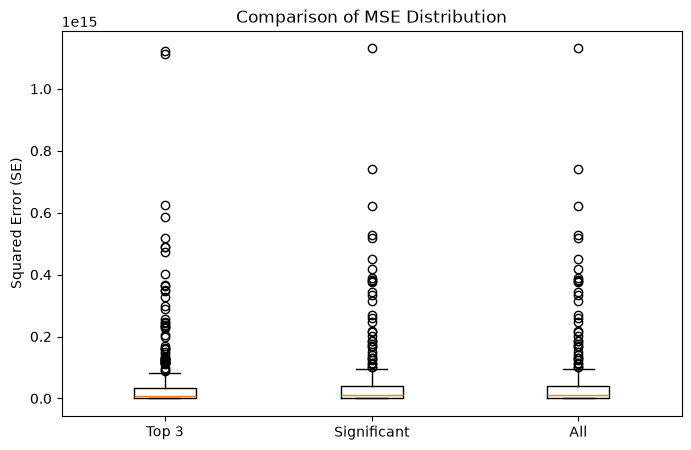

In [38]:
def evaluate_errors(y_true, y_pred):
  se = (y_true - y_pred) ** 2
  ae = np.abs(y_true - y_pred)
  return se, ae

se_top3, _ = evaluate_errors(y_test_arr, pred_top3)
se_sig, _ = evaluate_errors(y_test_arr, pred_sig)
se_all, _ = evaluate_errors(y_test_arr, pred_all)
plt.figure(figsize=(8, 5))
plt.boxplot([se_top3, se_sig, se_all], tick_labels=["Top 3", "Significant", "All"])
plt.title("Comparison of MSE Distribution")
plt.ylabel("Squared Error (SE)")
plt.show()

The scatter plots show that the predictions follow the ideal y = x line (red) for cheap and medium-priced properties, where most of the data is. The Significant and All Variables plots are identical. The Top 3 plot has a wider spread and no negative predictions, but it underestimates a part of the expensive houses. The vertical column at 5.5×10⁷ on the x-axis is the capped target (outliers of `Price` were clipped by the IQR bound), and for these luxury houses the linear model gives very different predictions (both too low and too high), which is the main source of the error.

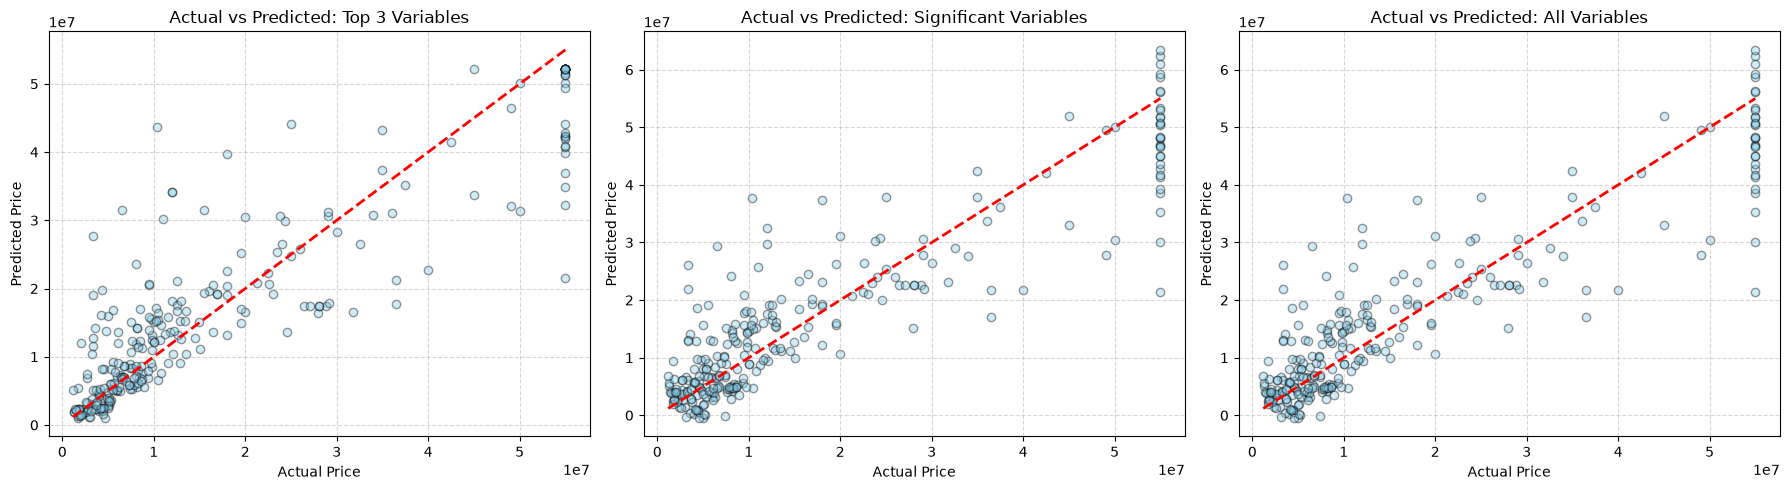

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_preds = [
    ("Top 3 Variables", pred_top3),
    ("Significant Variables", pred_sig),
    ("All Variables", pred_all),
]

for i, (name, preds) in enumerate(models_preds):
  axes[i].scatter(y_test_arr, preds, alpha=0.4, color="skyblue", edgecolors="k")
  axes[i].plot([y_test_arr.min(), y_test_arr.max()],[y_test_arr.min(), y_test_arr.max()],"r--",lw=2,)
  axes[i].set_title(f"Actual vs Predicted: {name}")
  axes[i].set_xlabel("Actual Price")
  axes[i].set_ylabel("Predicted Price")
  axes[i].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

The histograms show the residuals (actual minus predicted). For Significant and All Variables they are the same and are centered close to zero (mean about -1.4×10⁵, standard deviation about 7.3×10⁶), so the model is almost unbiased. The Top 3 model has a similar shape with a slightly larger spread (standard deviation about 7.6×10⁶). Long tails on both sides come from the expensive properties, where the linear model is least accurate.

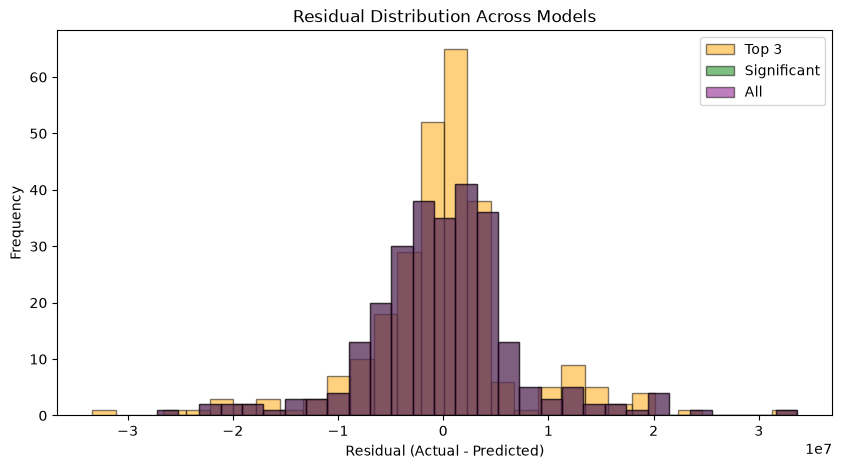

In [40]:
plt.figure(figsize=(10, 5))
plt.hist(y_test_arr - pred_top3,bins=30,alpha=0.5,label="Top 3",color="orange",edgecolor="black",)
plt.hist(y_test_arr - pred_sig,bins=30,alpha=0.5,label="Significant",color="green",edgecolor="black",)
plt.hist(y_test_arr - pred_all, bins=30,alpha=0.5,label="All",color="purple",edgecolor="black",)
plt.title("Residual Distribution Across Models")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [41]:
sk_results = {}
for name, cols in [("Top 3", X_top3_df.columns), ("Significant", X_sig_df.columns), ("All", X_train_df.columns)]:
    sk = LinearRegression()
    sk.fit(X_train_df[cols], y_train_list)
    sk_pred = sk.predict(X_test_df[cols])
    sk_mse = mean_squared_error(y_test_arr, sk_pred)
    sk_results[name] = {"MSE": sk_mse, "RMSE": np.sqrt(sk_mse), "MAE": mean_absolute_error(y_test_arr, sk_pred)}
    print(f"Scikit-Learn Metrics ({name} features):")
    print(f"MSE: {sk_results[name]['MSE']:.6f}")
    print(f"RMSE: {sk_results[name]['RMSE']:.6f}")
    print(f"MAE: {sk_results[name]['MAE']:.6f}\n")

Scikit-Learn Metrics (Top 3 features):
MSE: 57666953828032.976562
RMSE: 7593876.074050
MAE: 4855378.288108

Scikit-Learn Metrics (Significant features):
MSE: 53555077219022.796875
RMSE: 7318133.451846
MAE: 5107293.451057

Scikit-Learn Metrics (All features):
MSE: 53555077219022.789062
RMSE: 7318133.451846
MAE: 5107293.451057



The custom Gradient Descent models and Scikit-Learn `LinearRegression` give the same metrics for all three feature sets (for example, MSE 5.766695×10¹³ for Top 3, and 5.355508×10¹³ for Significant and for All Variables). The numbers coincide to all printed digits, which confirms that the custom implementation (with a converged Gradient Descent) is correct.

In [42]:
comparison_data = []
for name, custom in [("Top 3", metrics_top3), ("Significant", metrics_sig), ("All", metrics_all)]:
    comparison_data.append({"Features": name, "Implementation": "Custom (Gradient Descent)", **custom})
    comparison_data.append({"Features": name, "Implementation": "Scikit-Learn", **sk_results[name]})

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

   Features            Implementation          MSE         RMSE          MAE
      Top 3 Custom (Gradient Descent) 5.766695e+13 7.593876e+06 4.855378e+06
      Top 3              Scikit-Learn 5.766695e+13 7.593876e+06 4.855378e+06
Significant Custom (Gradient Descent) 5.355508e+13 7.318133e+06 5.107293e+06
Significant              Scikit-Learn 5.355508e+13 7.318133e+06 5.107293e+06
        All Custom (Gradient Descent) 5.355508e+13 7.318133e+06 5.107293e+06
        All              Scikit-Learn 5.355508e+13 7.318133e+06 5.107293e+06


In [43]:
def cap_outliers_single(df):
    df_copy = df.copy()
    for col, (lower_bound, upper_bound) in train_iqr.items():
        if col in df_copy.columns:
            df_copy[col] = df_copy[col].apply(lambda x: max(lower_bound, min(upper_bound, x)))
    return df_copy


def target_encode_location_single(df):
    df_copy = df.copy()
    df_copy['Location_encoded'] = df_copy['Location'].map(location_price_map).fillna(global_mean_price)
    df_copy = df_copy.drop(columns=['Location'])
    return df_copy


def preprocess_single_record(raw_record: dict):
    df = pd.DataFrame([raw_record])

    all_input_cols = [c for c in data.columns if c != 'Price']
    for col in all_input_cols:
        if col not in df.columns:
            df[col] = np.nan

    df = fill_missing_values(df)                           
    df = cap_outliers_single(df)                            

    df['Total_Rooms'] = df['Bedrooms'] + df['Bathrooms']    
    df['Total_Area'] = df['Floor Area'] + df['Land Area']
    df["Area_Per_Room"] = df["Total_Area"] / df["Total_Rooms"]
    df["Floor_To_Land_Ratio"] = (df["Floor Area"] / df["Land Area"])

    df = target_encode_location_single(df)                  
    if 'Longitude' in df.columns:                          
        df = df.drop(columns=['Longitude'])

    df = one_hot_encode(df)                                 
    for col in cols_to_normalize:
        if col not in df.columns:
            continue
        min_val, max_val = train_min[col], train_max[col]
        df[col] = 0.0 if max_val == min_val else (df[col] - min_val) / (max_val - min_val)
    df = df.reindex(columns=X_train_df.columns, fill_value=0)  
    return df


def predict_price(raw_record: dict, theta, columns=None):
    X_row = preprocess_single_record(raw_record)
    if columns is not None:
        X_row = X_row[columns]

    X_row_bias = np.r_[1.0, X_row.values.flatten()]
    predicted_price = X_row_bias @ np.array(theta)
    return predicted_price


example_record = {
    "Bedrooms": 3,
    "Bathrooms": 2,
    "Floor Area": 120,
    "Land Area": 200,
    "Location": "Quezon City",
    "Latitude": 14.65,  
}

predicted_price = predict_price(example_record, theta_sig, X_sig_df.columns)
print(f"Predicted price: {predicted_price:.2f}")

Predicted price: 11711887.47


The predicted price for a compact 3-bedroom, 2-bathroom property with 120 m² floor area and 200 m² land area in Quezon City is about 11.7 million. This is a plausible value: the median price in the training set is about 9.6 million, and the 75th percentile of the raw prices is 25 million. The record goes through exactly the same steps as the training data (imputation, capping, new features, target encoding with the mapping fitted on the training set, scaling).